**PROJECT: COVID-19 DATA ANALYSIS & DASHBOARD SYSTEM**

**OBJECTIVE 1 – DATA COLLECTION**

**Install Dashboard Libraries**

In [1]:
!pip install dash
!pip install jupyter-dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.5 MB/s eta 0:00:00


**Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from jupyter_dash import JupyterDash
from dash import dcc, html
from dash.dependencies import Input, Output

**Mount Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load Dataset from Google Drive**

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/country_wise_latest.csv")

df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


**OBJECTIVE 2 – DATA CLEANING & PREPROCESSING**

**Select Required Columns**

In [5]:
df = df[["Country/Region","Confirmed","Deaths","Recovered","Active"]]

df.columns = ["Country","Confirmed","Deaths","Recovered","Active"]

df.head()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667


**Check Missing Values**

In [6]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
Country      0
Confirmed    0
Deaths       0
Recovered    0
Active       0
dtype: int64


**Remove Duplicate Records**

In [7]:
df = df.drop_duplicates()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    187 non-null    object
 1   Confirmed  187 non-null    int64 
 2   Deaths     187 non-null    int64 
 3   Recovered  187 non-null    int64 
 4   Active     187 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.4+ KB


**OBJECTIVE 3 – DESCRIPTIVE STATISTICS**


**Global Statistics**

In [8]:
total_confirmed = df["Confirmed"].sum()
total_deaths = df["Deaths"].sum()
total_recovered = df["Recovered"].sum()
total_active = df["Active"].sum()

print("Total Confirmed Cases:", total_confirmed)
print("Total Deaths:", total_deaths)
print("Total Recovered:", total_recovered)
print("Total Active:", total_active)

Total Confirmed Cases: 16480485
Total Deaths: 654036
Total Recovered: 9468087
Total Active: 6358362


**Statistical Summary**

In [9]:
df.describe()

,Confirmed,Deaths,Recovered,Active
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


**OBJECTIVE 4 – COUNTRY BASED ANALYSIS**

**Top 10 Countries by Confirmed Cases**

/tmp/ipykernel_9580/3822407846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


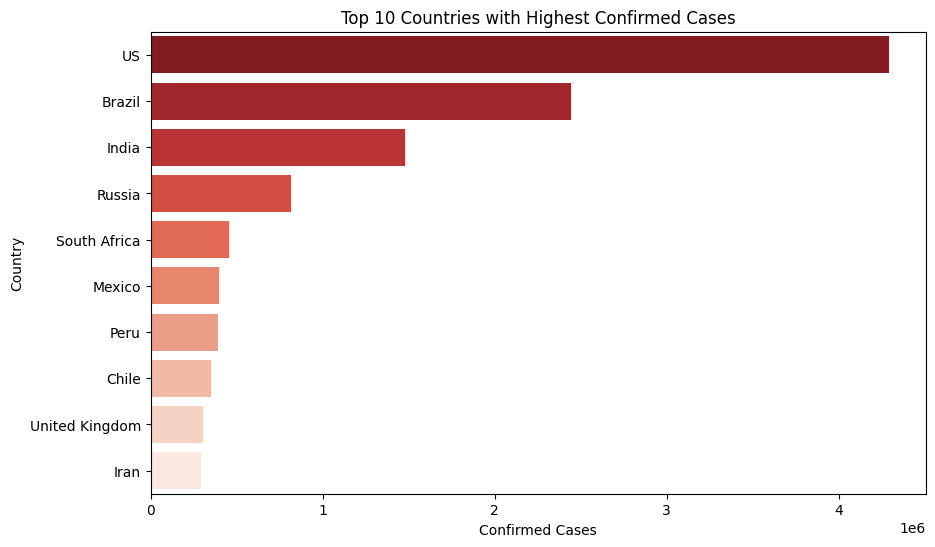

In [10]:
top10 = df.sort_values(by="Confirmed",ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Confirmed",
    y="Country",
    data=top10,
    palette="Reds_r"
)

plt.title("Top 10 Countries with Highest Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")

plt.show()

**Top Countries by Deaths**

/tmp/ipykernel_9580/3760591005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


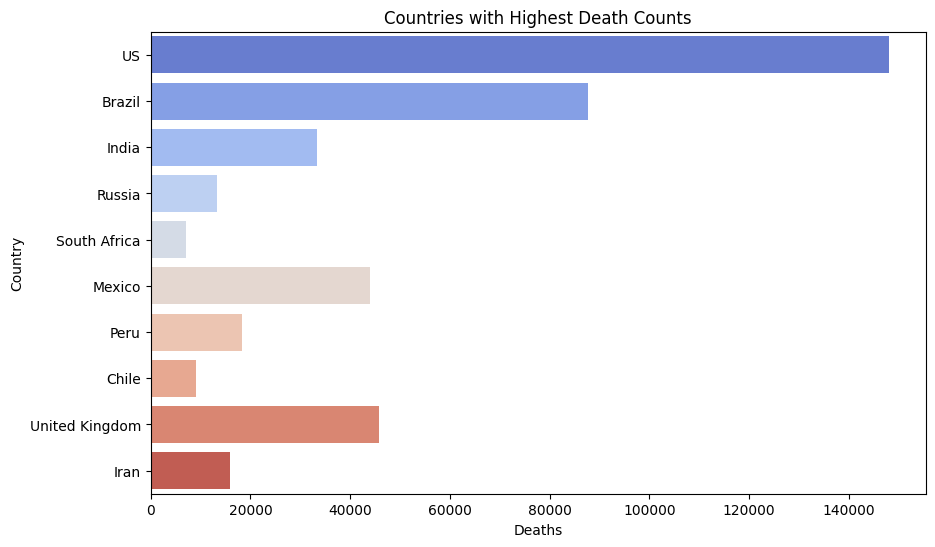

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Deaths",
    y="Country",
    data=top10,
    palette="coolwarm"
)

plt.title("Countries with Highest Death Counts")

plt.show()

**OBJECTIVE 5 – CASE DISTRIBUTION ANALYSIS**

**Pie Chart**

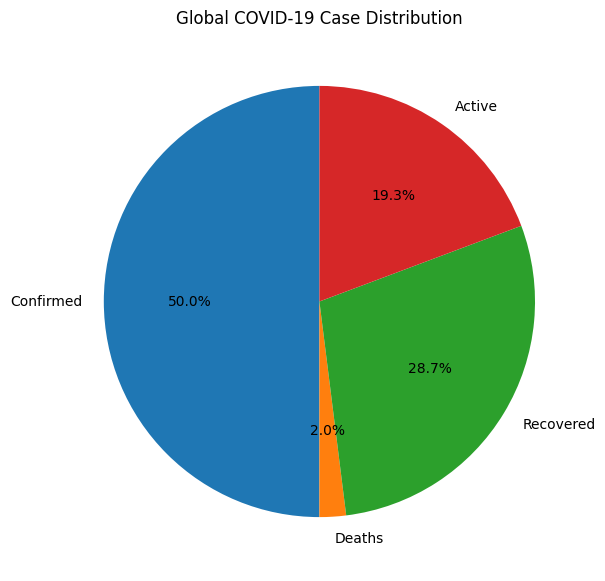

In [12]:
cases = [total_confirmed,total_deaths,total_recovered,total_active]

labels = ["Confirmed","Deaths","Recovered","Active"]

plt.figure(figsize=(7,7))

plt.pie(
    cases,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Global COVID-19 Case Distribution")

plt.show()

**OBJECTIVE 6 – RELATIONSHIP ANALYSIS**

**Confirmed vs Deaths**

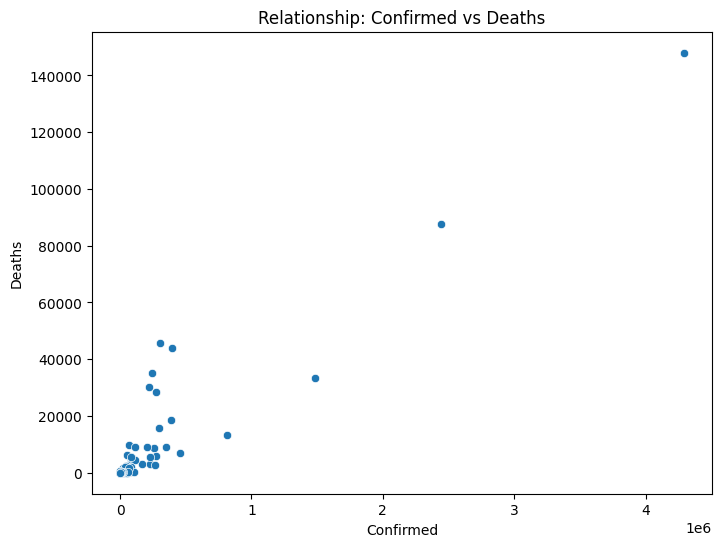

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Confirmed",
    y="Deaths",
    data=df
)

plt.title("Relationship: Confirmed vs Deaths")

plt.show()

**Confirmed vs Recovered**

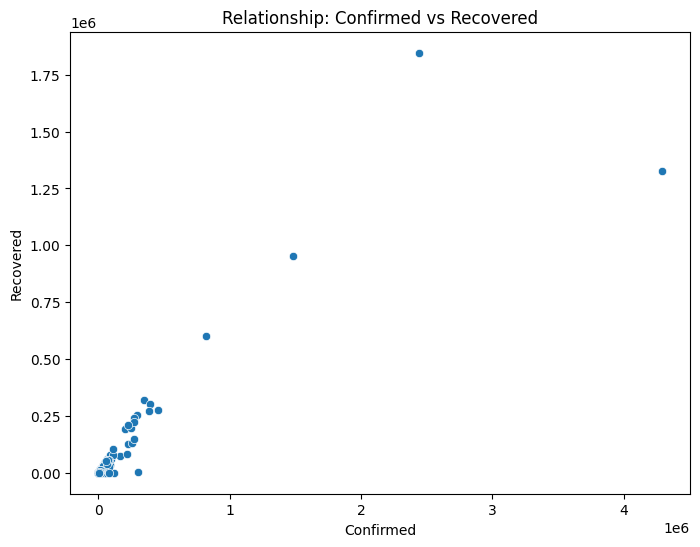

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Confirmed",
    y="Recovered",
    data=df
)

plt.title("Relationship: Confirmed vs Recovered")

plt.show()

**Active vs Confirmed**

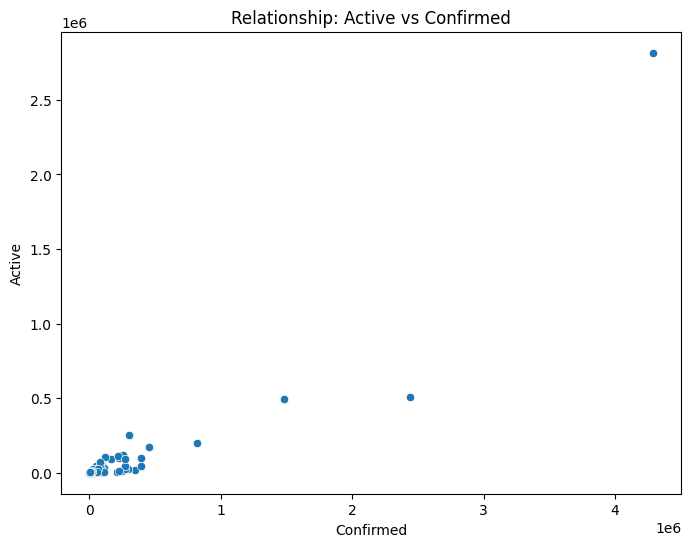

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Confirmed",
    y="Active",
    data=df
)

plt.title("Relationship: Active vs Confirmed")

plt.show()

**OBJECTIVE 7 – CORRELATION ANALYSIS**

**Correlation Heatmap**

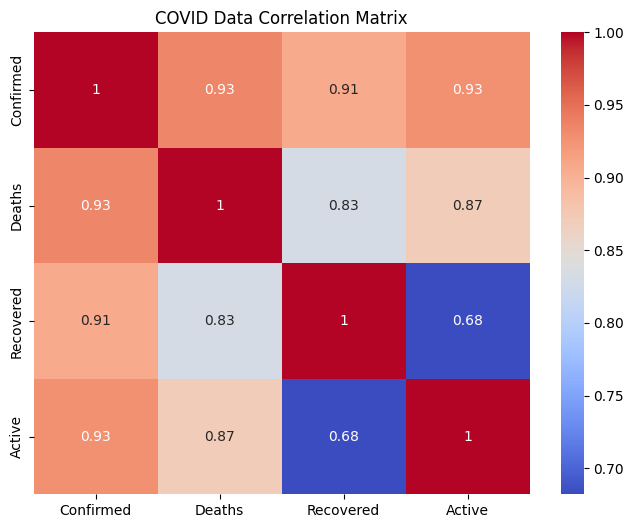

In [17]:
plt.figure(figsize=(8,6))

corr = df.drop('Country', axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("COVID Data Correlation Matrix")

plt.show()

**OBJECTIVE 8 – INTERACTIVE DATA VISUALIZATION**

**Interactive Bar Chart**

In [18]:
fig = px.bar(
    top10,
    x="Country",
    y="Confirmed",
    color="Confirmed",
    title="Top 10 Countries by Confirmed Cases"
)

fig.show()

**Interactive Scatter Plot**

In [19]:
fig = px.scatter(
    df,
    x="Confirmed",
    y="Deaths",
    hover_name="Country",
    size="Active",
    color="Recovered",
    title="COVID Relationship Analysis"
)

fig.show()

**OBJECTIVE 9 – INTERACTIVE DASHBOARD**

**Dashboard Layout**

In [20]:
app = JupyterDash(__name__)

app.layout = html.Div([

    html.H1("COVID-19 Data Analysis Dashboard",
            style={'textAlign':'center'}),

    dcc.Dropdown(
        id='country-dropdown',
        options=[{'label':i,'value':i} for i in df['Country']],
        value=df['Country'].iloc[0]
    ),

    dcc.Graph(id='covid-graph')

])

/usr/local/lib/python3.12/dist-packages/dash/dash.py:644: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



**Dashboard Callback**

In [22]:
@app.callback(
    Output('covid-graph','figure'),
    Input('country-dropdown','value')
)

def update_graph(selected_country):

    filtered = df[df["Country"] == selected_country]

    fig = px.bar(
        x=["Confirmed","Deaths","Recovered","Active"],
        y=[
           filtered["Confirmed"].values[0],
           filtered["Deaths"].values[0],
           filtered["Recovered"].values[0],
           filtered["Active"].values[0]
        ],
        labels={'x':'Case Type','y':'Count'},
        title=f"COVID Statistics for {selected_country}"
    )

    return fig

**Run Dashboard**

In [30]:
app.run()

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


**OBJECTIVE 10 – DASHBOARD INSIGHTS**

**Identify High-Risk Countries**

/tmp/ipykernel_9580/2835890679.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




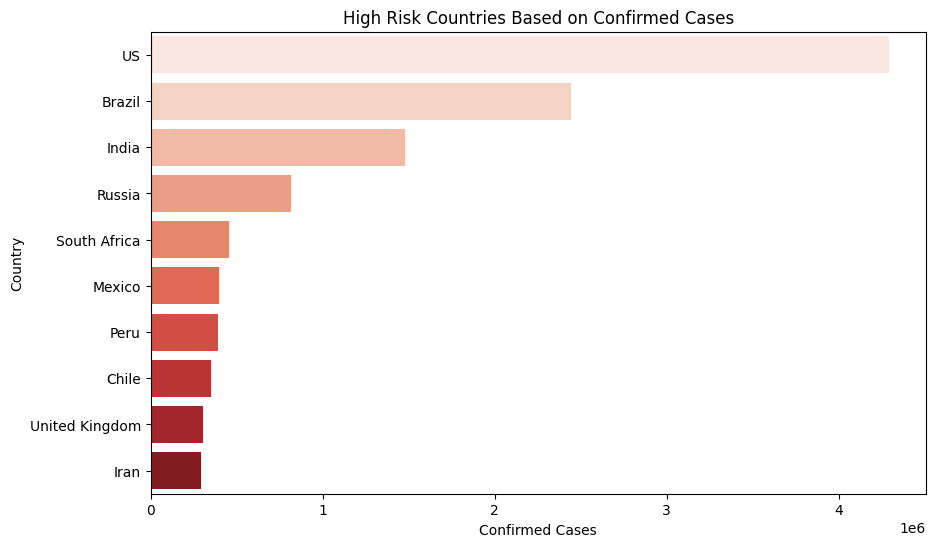

In [31]:
high_risk = df.sort_values(by="Confirmed", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Confirmed",
    y="Country",
    data=high_risk,
    palette="Reds"
)

plt.title("High Risk Countries Based on Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")

plt.show()

**Analyze Recovery Trends**

/tmp/ipykernel_9580/2500493116.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




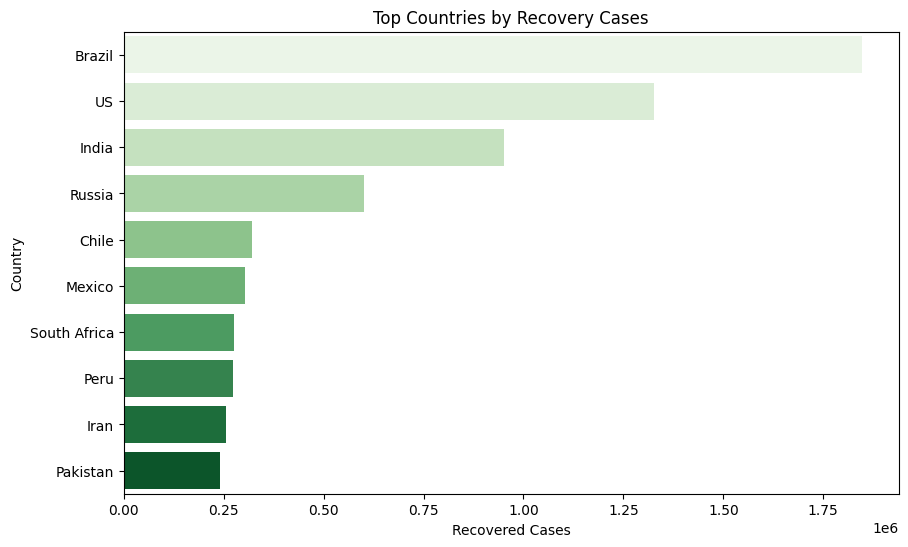

In [32]:
recovery = df.sort_values(by="Recovered", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Recovered",
    y="Country",
    data=recovery,
    palette="Greens"
)

plt.title("Top Countries by Recovery Cases")
plt.xlabel("Recovered Cases")
plt.ylabel("Country")

plt.show()

**Observe Pandemic Patterns**

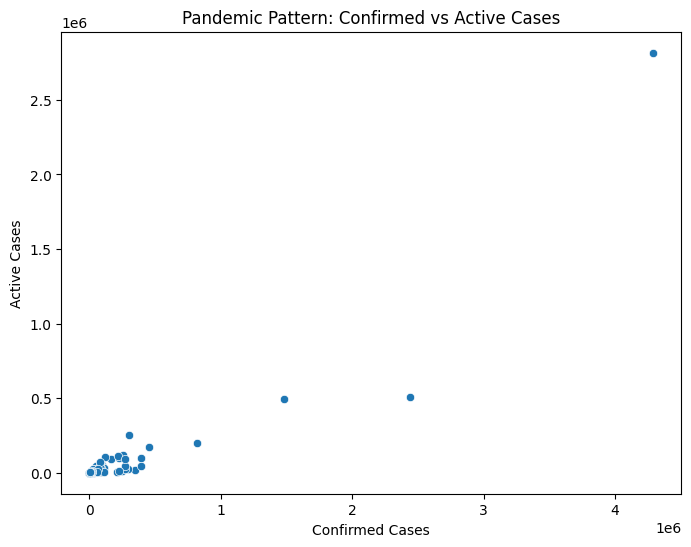

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Confirmed",
    y="Active",
    data=df
)

plt.title("Pandemic Pattern: Confirmed vs Active Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Active Cases")

plt.show()

**INSIGHTS & CONCLUSION**

**Project Insights**

In [34]:
print("COVID-19 DATA ANALYSIS INSIGHTS")

print("1. Countries with higher confirmed cases are considered high-risk regions.")
print("2. Recovery trends indicate improvement in healthcare response.")
print("3. There is a strong relationship between confirmed cases and deaths.")
print("4. Active cases represent the current pandemic burden in each country.")
print("5. Data visualization helps understand COVID spread patterns.")
print("6. Interactive dashboards support better decision-making.")

COVID-19 DATA ANALYSIS INSIGHTS
1. Countries with higher confirmed cases are considered high-risk regions.
2. Recovery trends indicate improvement in healthcare response.
3. There is a strong relationship between confirmed cases and deaths.
4. Active cases represent the current pandemic burden in each country.
5. Data visualization helps understand COVID spread patterns.
6. Interactive dashboards support better decision-making.
